In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
folder_to_read = "C:\\Users\\Elouan\\Documents\\Projet Biais LLM\\Post Treatment 2.0\\files"
all_files = os.listdir(folder_to_read)
print(all_files)
models = []
for file in all_files:
    if file.endswith(".csv"):
        model_name = file.split("_")[0]
        if model_name not in models:
            models.append(model_name)
print(models)

#create a folder per model
for model in models:
    model_folder = "C:\\Users\\Elouan\\Documents\\Projet Biais LLM\\Post Treatment 2.0\\" + model
    if not os.path.exists(model_folder):
        os.makedirs(model_folder)

merged_df = pd.read_csv('C:\\Users\\Elouan\\Documents\\Projet Biais LLM\\Post Treatment 2.0\\merged_model_responses.csv')
df = merged_df[['index', 'song_title', 'artist', 'original_gender',
       'original_continent', 'source', 'lyrics']]
print(df.shape)
print(df.columns)
df.head()

['DeepSeek-R1-Distill-Qwen-1.5B_gender_classification_merged.csv', 'DeepSeek-R1-Distill-Qwen-7B_gender_classification_merged.csv', 'desktop.ini', 'Gemma-3-12b-it_gender_classification_merged.csv', 'Llama-3.1-8B-Instruct_gender_classification_merged.csv', 'Ministral-8B-Instruct-2410_gender_classification_merged.csv', 'Qwen-2.5-7B-Instruct_gender_classification_merged.csv']
['DeepSeek-R1-Distill-Qwen-1.5B', 'DeepSeek-R1-Distill-Qwen-7B', 'Gemma-3-12b-it', 'Llama-3.1-8B-Instruct', 'Ministral-8B-Instruct-2410', 'Qwen-2.5-7B-Instruct']
(10808, 7)
Index(['index', 'song_title', 'artist', 'original_gender',
       'original_continent', 'source', 'lyrics'],
      dtype='object')


,index,song_title,artist,original_gender,original_continent,source,lyrics
0,0,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,Male,North America,spotify,i really cannot stay baby it is cold outside g...
1,1,Soldier,James TW,Male,Europe,spotify,hold your breath do not look down keep trying ...
2,2,Satisfy You,Diddy,Male,North America,spotify,all i want is somebody who is going to love me...
3,3,Tender Lover,Babyface,Male,North America,spotify,feels good everybody tender lover tender love ...
4,4,Ti volevo dedicare (feat. J-AX & Boomdabash),Rocco Hunt,Male,Europe,spotify,I have something to tell you that I've been wa...


In [4]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

df['lyrics'] = df['lyrics'].astype(str).str.lower()

def clean_string(s):
    if isinstance(s, str):
        for char in ['-', '_', '.', ',', ';', ':', '!', '?', '"', "'", '(', ')', '[', ']', '{', '}', '/', '\\', '|', '@', '#', '$', '%', '^', '&', '*', '~', '`']:
            s = s.replace(char, ' ')
        s = s.strip()
    return s

df['word_count'] = df['lyrics'].apply(lambda x: len(x.split()))
#filter with stop words
df['cleaned_lyrics'] = df['lyrics'].apply(clean_string)
df['cleaned_lyrics'] = df['cleaned_lyrics'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
df['word_count_clean'] = df['cleaned_lyrics'].apply(lambda x: len(x.split()))
df['unique_word_count'] = df['cleaned_lyrics'].apply(lambda x: len(set(x.split())))
df['mean_word_length'] = df['cleaned_lyrics'].apply(lambda x: sum(len(word) for word in x.split()) / len(x.split()) if len(x.split()) > 0 else 0)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Elouan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\Elouan\AppData\Local\Temp\ipykernel_16120\2975214840.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lyrics'] = df['lyrics'].astype(str).str.lower()
C:\Users\Elouan\AppData\Local\Temp\ipykernel_16120\2975214840.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count'] = df['lyrics'].apply(lambda x: len(x.split()))
C:\Use

In [5]:
#create a folder words_stats
words_stats_folder = "C:\\Users\\Elouan\\Documents\\Projet Biais LLM\\Post Treatment 2.0\\words_stats"
if not os.path.exists(words_stats_folder):
    os.makedirs(words_stats_folder)
df.to_csv(os.path.join(words_stats_folder, 'lyrics_word_stats.csv'), index=False)

C:\Users\Elouan\AppData\Local\Temp\ipykernel_16120\2156105712.py:15: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.3`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(data=df[cols], palette="tab10", cut=0, inner='quartile', bw=0.3)


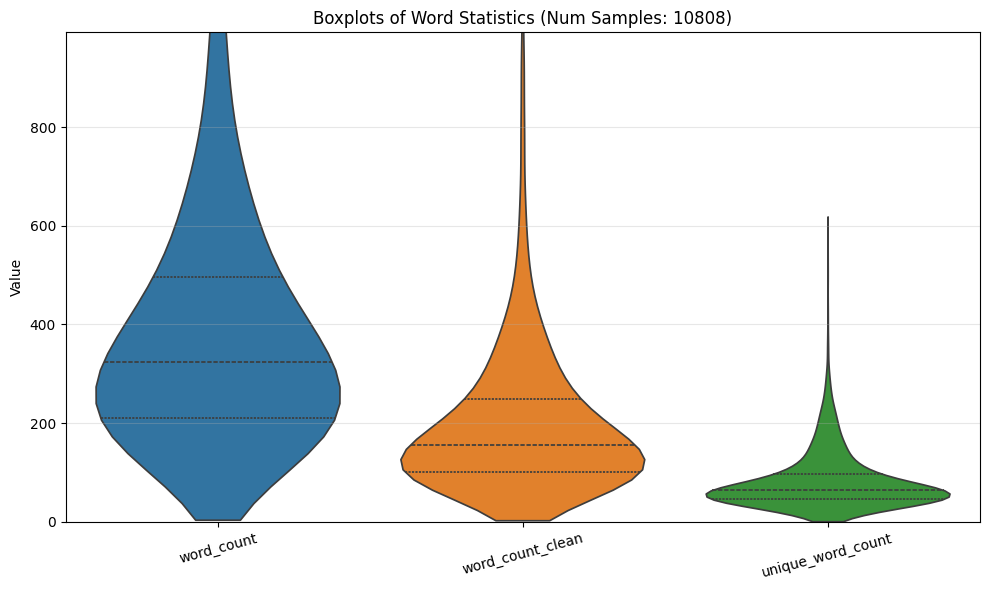

C:\Users\Elouan\AppData\Local\Temp\ipykernel_16120\2156105712.py:34: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.3`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(data=df_melt_gender, x='metric', y='value', hue='original_gender', palette='tab10', cut=0, inner='quartile', bw=0.3)


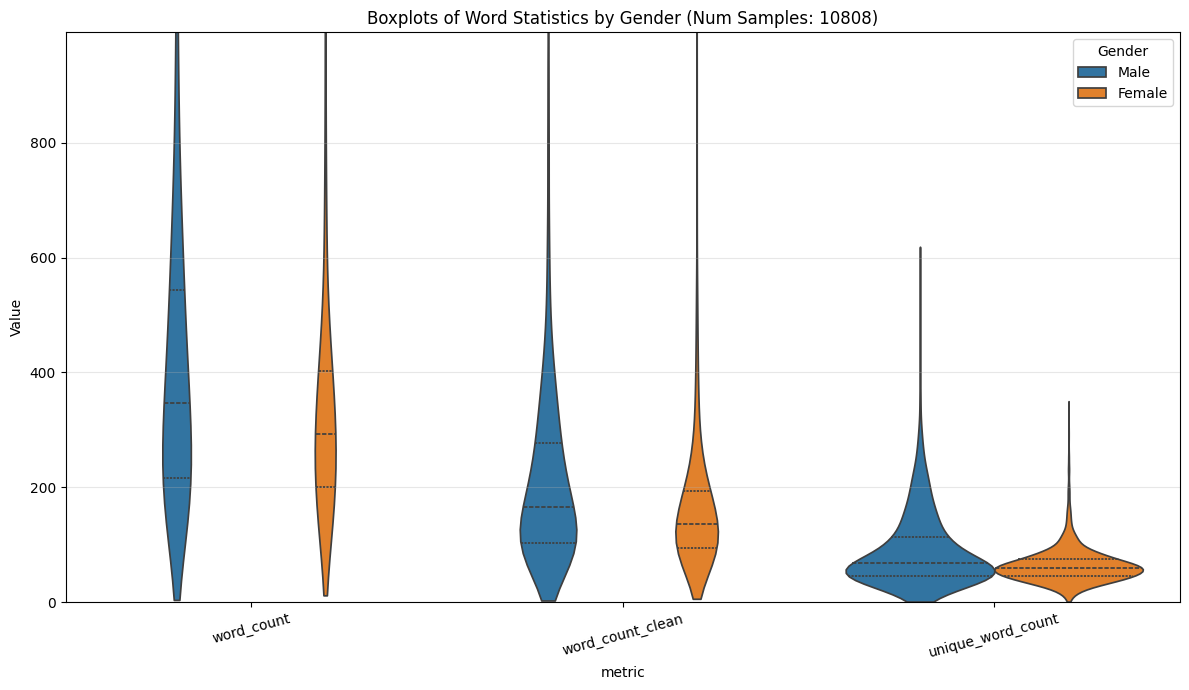

C:\Users\Elouan\AppData\Local\Temp\ipykernel_16120\2156105712.py:54: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.3`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(data=df_melt_cont, x='metric', y='value', hue='original_continent', palette='tab10', cut=0, inner='quartile', bw=0.3)


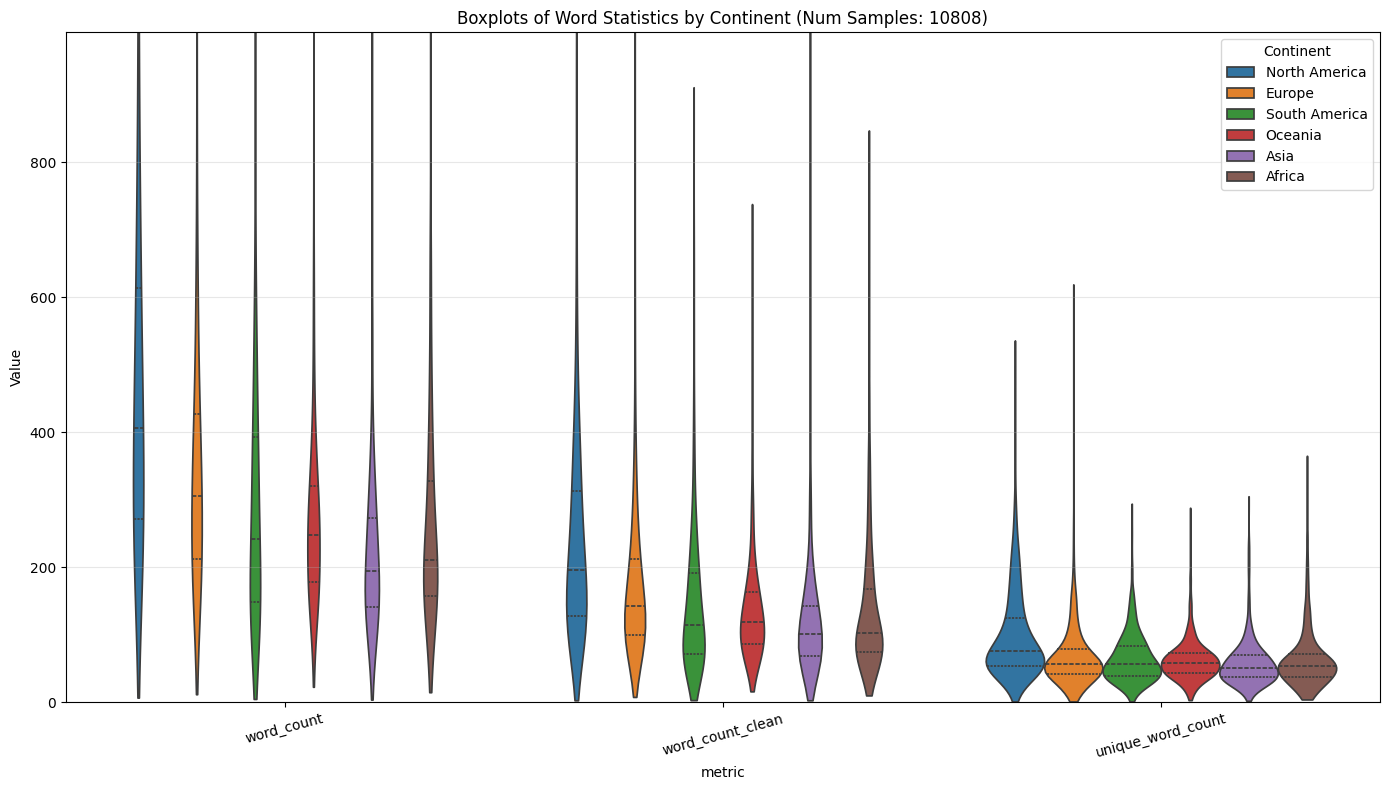

In [9]:
list_scores = ['word_count', 'word_count_clean', 'unique_word_count']
import seaborn as sns

cols = list_scores

q1 = df[cols].quantile(0.25)
q3 = df[cols].quantile(0.75)
iqr = q3 - q1
whisker_max = (q3 + 1.5 * iqr).max()

ylim_max = whisker_max * 1.07  # 7% margin

# --- 1) Global boxplot for word stats ---
plt.figure(figsize=(10, 6))
sns.violinplot(data=df[cols], palette="tab10", cut=0, inner='quartile', bw=0.3)
plt.title(f'Boxplots of Word Statistics (Num Samples: {len(df)})')
plt.ylabel('Value')
plt.ylim(0, ylim_max)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(words_stats_folder, 'boxplot_words_stats.png'), bbox_inches='tight')
plt.show()

# --- 2) Boxplot by gender ---
df_melt_gender = df.melt(
    id_vars='original_gender',
    value_vars=cols,
    var_name='metric',
    value_name='value'
)

plt.figure(figsize=(12, 7))
sns.violinplot(data=df_melt_gender, x='metric', y='value', hue='original_gender', palette='tab10', cut=0, inner='quartile', bw=0.3)
plt.title(f'Boxplots of Word Statistics by Gender (Num Samples: {len(df)})')
plt.ylabel('Value')
plt.ylim(0, ylim_max)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig(os.path.join(words_stats_folder, 'boxplot_words_stats_by_gender.png'), bbox_inches='tight')
plt.show()

# --- 3) Boxplot by continent ---
df_melt_cont = df.melt(
    id_vars='original_continent',
    value_vars=cols,
    var_name='metric',
    value_name='value'
)

plt.figure(figsize=(14, 8))
sns.violinplot(data=df_melt_cont, x='metric', y='value', hue='original_continent', palette='tab10', cut=0, inner='quartile', bw=0.3)
plt.title(f'Boxplots of Word Statistics by Continent (Num Samples: {len(df)})')
plt.ylabel('Value')
plt.ylim(0, ylim_max)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.legend(title='Continent')
plt.tight_layout()
plt.savefig(os.path.join(words_stats_folder, 'boxplot_words_stats_by_continent.png'), bbox_inches='tight')
plt.show()

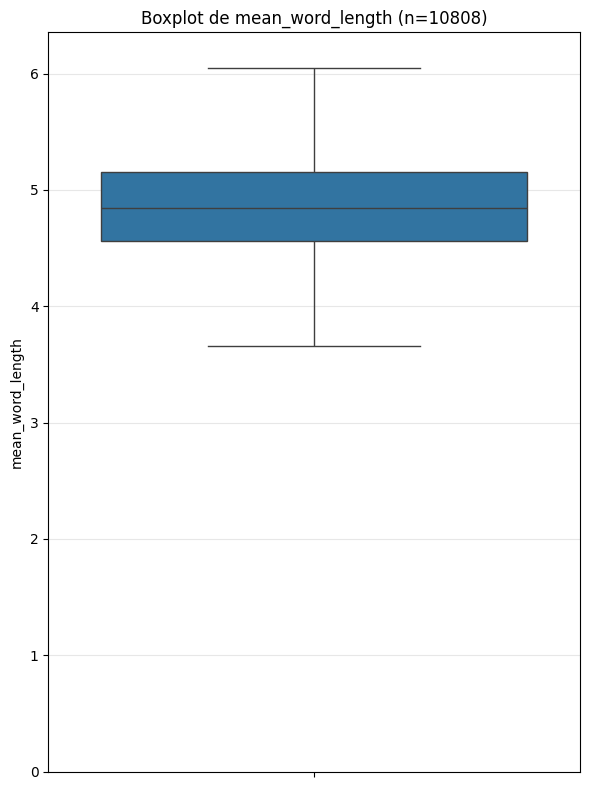

In [7]:
# Boxplot pour mean_word_length uniquement
# compute quantiles directly from the mean_word_length column to avoid KeyError
q1_mean = df['mean_word_length'].quantile(0.25)
q3_mean = df['mean_word_length'].quantile(0.75)
iqr_mean = q3_mean - q1_mean
whisker_max_mean = q3_mean + 1.5 * iqr_mean
ylim_max_mean = whisker_max_mean * 1.05

plt.figure(figsize=(6, 8))
sns.boxplot(data=df, y='mean_word_length', color='tab:blue', showfliers=False)
plt.title(f'Boxplot de mean_word_length (n={len(df)})')
plt.ylabel('mean_word_length')
plt.ylim(0, ylim_max_mean)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(words_stats_folder, 'boxplot_mean_word_length.png'), bbox_inches='tight')
plt.show()
